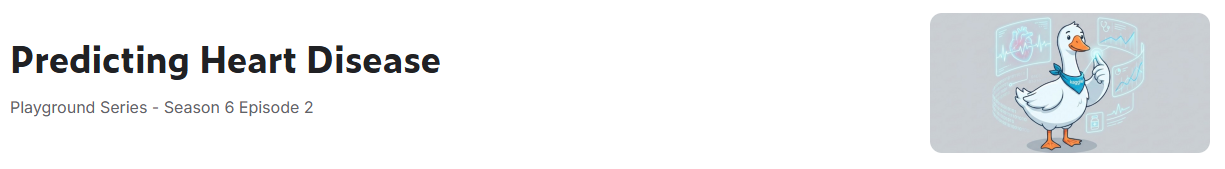

https://www.kaggle.com/competitions/playground-series-s6e2/overview

# **[0] Data Info**

<pre>
id              : ID
age             : 나이
sex             : 성별
chest pain type : 흉통 유형
bp              : 혈압
cholesterol     : 콜레스테롤
fbs over 120    : 공복 혈당 120 초과 여부
ekg results     : 심전도 결과
max hr          : 최대 심박수
exercise angina : 운동 유발 협심증
st depression   : ST 분절 하강
slope of st     : ST 분절 경사
number of vessels fluro : 혈관 조영술상 혈관 수
thallium        : 탈륨 검사 결과
heart disease   : 심장병

In [2]:
from sklearn import set_config
set_config(display="text")          #인코딩 텍스트로 바꿔달라는

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
sns.set()

import warnings
warnings.filterwarnings('ignore')


#----------차트 속성 (한글처리/그리드)
plt.rcParams['font.family']= 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False



#----------문제/답 분리
from sklearn.model_selection import train_test_split 


#----------분류모델
from sklearn.linear_model import LogisticRegression   #선형모델 
from sklearn.ensemble import RandomForestClassifier   #트리모델

#----------모델결합(Ensembles)
from sklearn.ensemble import VotingClassifier, VotingRegressor   #앙상블


#----------평가 매트릭스
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score, precision_recall_curve
from sklearn.metrics import roc_auc_score, roc_curve
from sklearn.metrics import confusion_matrix, classification_report


#----------교차검증
from sklearn.model_selection import GridSearchCV, KFold, StratifiedKFold, cross_val_score, cross_validate


#----------인코딩(글자->숫자)
from sklearn.preprocessing import LabelEncoder, OneHotEncoder


#----------정규화(스케일링)
from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler 


#----------차원 축소
from sklearn.decomposition import PCA 

# **[1] Data Load**
* target : heart disease

In [9]:
train = pd.read_csv("../../Datas/#disease/train.csv") 
test = pd.read_csv("../../Datas/#disease/test.csv")
sub = pd.read_csv("../../Datas/#disease/sample_submission.csv")

### 컬럼 소문자 변경

In [10]:
train.columns = train.columns.str.lower()
test.columns = test.columns.str.lower()

### 컬럼 이름 변경

In [12]:
train.columns

Index(['id', 'age', 'sex', 'chest pain type', 'bp', 'cholesterol',
       'fbs over 120', 'ekg results', 'max hr', 'exercise angina',
       'st depression', 'slope of st', 'number of vessels fluro', 'thallium',
       'heart disease'],
      dtype='str')

<pre>
'ID', '나이', '성별', '흉통 유형', '혈압', '콜레스테롤', '공복 혈당 120 초과 여부', '심전도 결과', '최대 심박수', '운동 유발 협심증', 'ST 분절 하강', 'ST 분절 경사', '혈관 조영술상 혈관 수', '탈륨 검사 결과', '심장병'
    
'id', 'age', 'sex', 'chest pain type', 'bp', 'cholesterol', 'fbs over 120', 'ekg results', 'max hr', 'exercise angina', 'st depression', 'slope of st', 'number of vessels fluro', 'thallium', 'heart disease'

In [14]:
train = train.rename(columns={'chest pain type':'c_pain',
                              'cholesterol' : 'chol',
                              'fbs over 120': 'fbs',
                              'ekg results' : 'ekg',
                              'max hr' : 'hr', 
                              'exercise angina' : 'angina', 
                              'st depression' : 'st_d',
                              'slope of st' : 'sl_s',
                              'number of vessels fluro' : 'vessels'})

test = test.rename(columns={'chest pain type':'c_pain',
                              'cholesterol' : 'chol',
                              'fbs over 120': 'fbs',
                              'ekg results' : 'ekg',
                              'max hr' : 'hr', 
                              'exercise angina' : 'angina', 
                              'st depression' : 'st_d',
                              'slope of st' : 'sl_s',
                              'number of vessels fluro' : 'vessels'})

In [15]:
train.head(2)

,id,age,sex,c_pain,bp,chol,fbs,ekg,hr,angina,st_d,sl_s,vessels,thallium,heart disease
0,0,58,1,4,152,239,0,0,158,1,3.6,2,2,7,Presence
1,1,52,1,1,125,325,0,2,171,0,0.0,1,0,3,Absence


In [16]:
train.info()

<class 'pandas.DataFrame'>
RangeIndex: 630000 entries, 0 to 629999
Data columns (total 15 columns):
 #   Column         Non-Null Count   Dtype  
---  ------         --------------   -----  
 0   id             630000 non-null  int64  
 1   age            630000 non-null  int64  
 2   sex            630000 non-null  int64  
 3   c_pain         630000 non-null  int64  
 4   bp             630000 non-null  int64  
 5   chol           630000 non-null  int64  
 6   fbs            630000 non-null  int64  
 7   ekg            630000 non-null  int64  
 8   hr             630000 non-null  int64  
 9   angina         630000 non-null  int64  
 10  st_d           630000 non-null  float64
 11  sl_s           630000 non-null  int64  
 12  vessels        630000 non-null  int64  
 13  thallium       630000 non-null  int64  
 14  heart disease  630000 non-null  str    
dtypes: float64(1), int64(13), str(1)
memory usage: 72.1 MB


### 인코딩

In [18]:
train['heart disease'].value_counts()

heart disease
Absence     347546
Presence    282454
Name: count, dtype: int64

In [20]:
train['heart disease'] = train['heart disease'].map({"Presence":0, "Absence":1})
train.head(2)

,id,age,sex,c_pain,bp,chol,fbs,ekg,hr,angina,st_d,sl_s,vessels,thallium,heart disease
0,0,58,1,4,152,239,0,0,158,1,3.6,2,2,7,0
1,1,52,1,1,125,325,0,2,171,0,0.0,1,0,3,1


# **[2] EDA(Exploratory Data Analysis)**

## **시각화 hist()**
* 데이터 분포도 확인(왜도, 첨도, 정규분포)

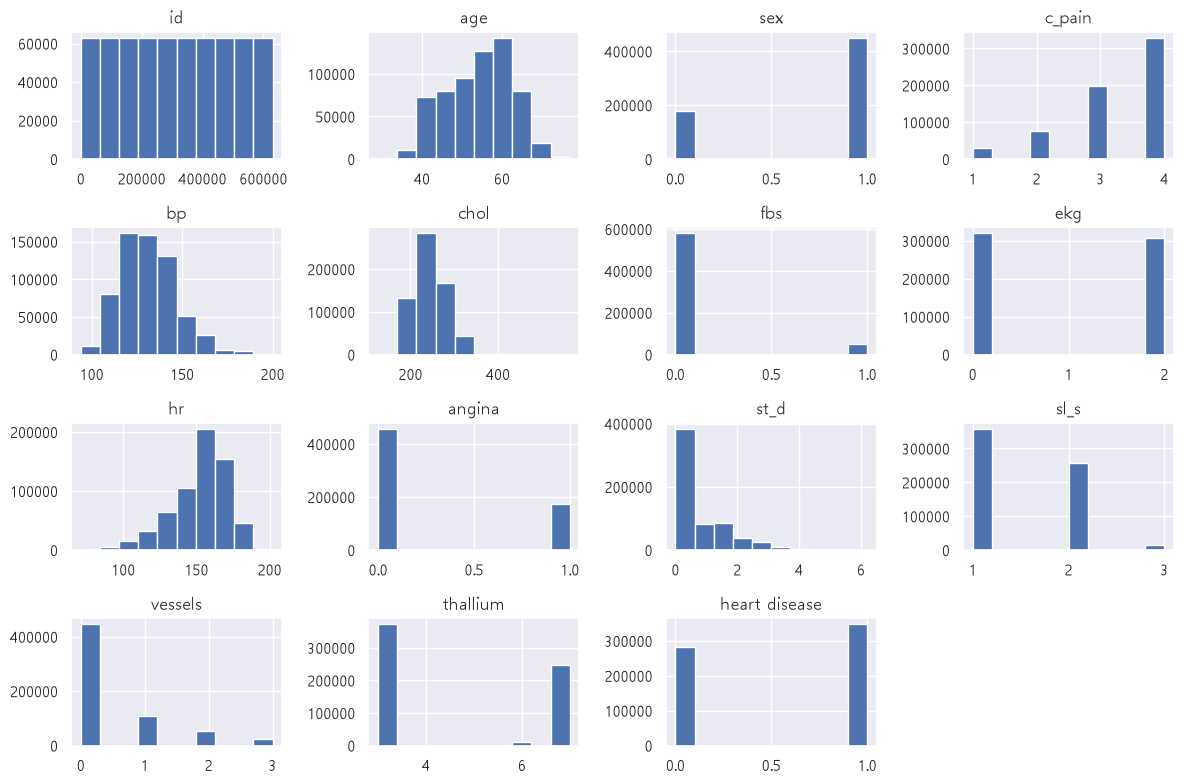

In [21]:
train.hist(figsize=(12, 8))
plt.tight_layout()
plt.show()

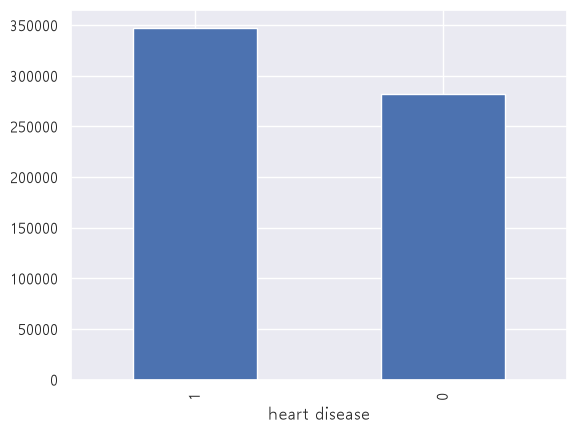

In [22]:
train['heart disease'].value_counts().plot.bar()
plt.show()

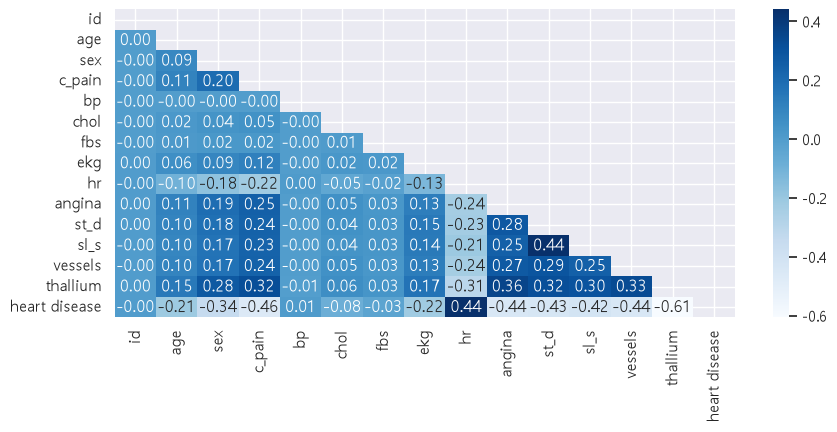

In [25]:
plt.figure(figsize=(10, 4))

# 반쪽으로 보기
mask = np.triu(np.ones_like(train.corr(), dtype=bool))
sns.heatmap(train.corr(), annot=True, fmt=".2f", cmap="Blues", mask=mask)    #.2f = 소수점 2자리까지~ (d=숫자로)
plt.show()